# <font color='rosybrown'> Examen 4
## <font color='rosybrown'> Arantza Gomez Haro Gamboa

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation,LGBMRegressor
import lightgbm as lgb
import shap
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [2]:
def calibracion_multiple(modelos, y, bins):
    for nombre, predicciones in modelos.items():
        df_calibracion = pd.DataFrame({
            'predicciones': predicciones,
            'y': y
        })
        
        df_calibracion['bins'] = pd.qcut(df_calibracion['predicciones'], q=bins, labels=False, duplicates='drop') + 1
        grouped = df_calibracion.groupby('bins').mean()
        
        plt.figure()
    
        plt.plot(grouped.predicciones, grouped.y, label=f"{nombre} (Modelo)", marker="o", color="rosybrown")
        plt.plot(grouped.predicciones, grouped.predicciones, label="Real", marker="o", color="cornflowerblue")
        
        plt.grid()
        plt.legend()
        plt.xlabel("Predicción")
        plt.ylabel("Real")
        plt.title(f"Calibración para {nombre}")

## <font color='cornflowerblue'> Datos

In [3]:
df = pd.read_csv('hr_role.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df)

target = 'Attrition'
y = df[target]
X = df.copy()
X = X.drop(target, axis = 1)

## <font color='cornflowerblue'> PCA

In [4]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA())
])

pipeline.fit(X)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA())])

In [5]:
objeto_pca = pipeline.named_steps['pca']
X_pca = pipeline.transform(X)
x_components = pd.DataFrame(X_pca,index=X.index, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
x_components.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC44,PC45,PC46,PC47,PC48,PC49,PC50,PC51,PC52,PC53
0,-0.030304,-2.330446,-1.161395,3.217517,-0.113925,0.253495,-1.040500,0.309246,-0.448044,2.111620,...,0.014891,1.531962e-15,2.086084e-15,6.192959e-17,4.532546e-16,-5.432506e-16,-1.944498e-32,-6.963223e-16,-4.254345e-16,-6.085001e-16
1,0.049651,1.543678,-0.213908,-1.662470,0.719564,-2.208041,1.095471,-1.080794,2.427347,1.248215,...,-0.102855,-2.571133e-16,1.024939e-15,-1.555732e-15,-1.219919e-16,4.310296e-16,6.783304e-32,2.361651e-15,-5.550595e-16,3.965348e-16
2,-2.921983,0.996320,-0.206778,1.584724,-0.095803,0.098296,-2.782596,0.838934,0.416457,-0.642975,...,-0.099216,1.573595e-15,-6.270238e-16,2.007075e-16,7.308103e-16,4.004389e-16,1.136990e-32,-5.100518e-17,-9.236764e-17,-6.085001e-16
3,-1.187400,1.054261,-0.692836,2.306721,-0.228501,-2.392424,1.058589,-0.071526,-1.843889,1.818120,...,0.045951,-7.856287e-16,-4.327348e-16,-8.574739e-16,-1.139222e-15,-3.212060e-16,4.526627e-32,1.302079e-15,-4.254345e-16,2.796783e-16
4,-2.122667,1.196360,0.532758,-1.288092,-0.694017,1.685820,-0.501539,0.272690,-0.631277,-1.714992,...,0.148985,-4.236468e-16,-8.901959e-16,-4.177530e-16,-4.828144e-16,-7.902157e-16,1.852923e-32,3.018256e-17,2.498522e-16,5.075571e-16


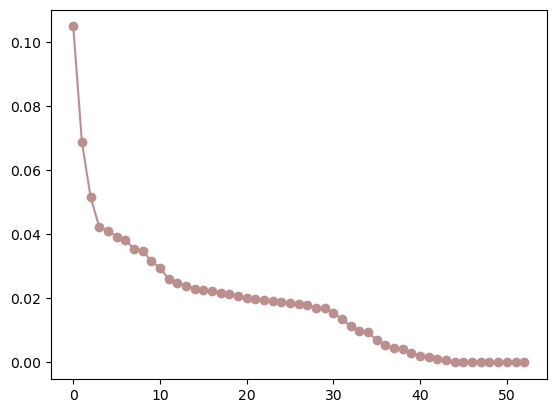

In [6]:
plt.plot(objeto_pca.explained_variance_ratio_, marker='o', color = 'rosybrown')

#### <font color='cornflowerblue'> Análisis:

## <font color='cornflowerblue'> Modelo KMeans

### <font color='cornflowerblue'> Gráfica del codo

c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'Loss Function')

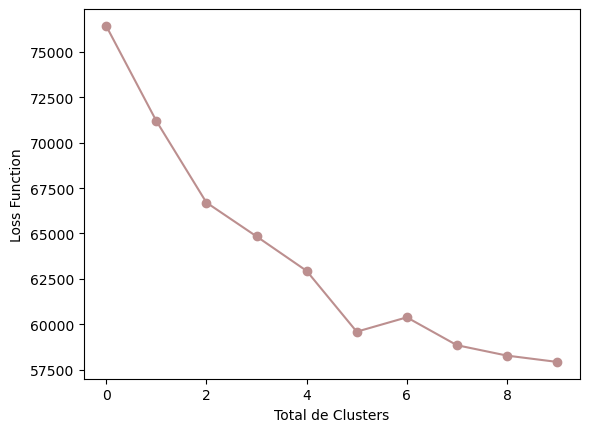

In [7]:
inertias = []

K_range = range(1, 11)
for i in K_range:
    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=i, random_state = 42))
    ])
    pipeline.fit(df)
    inertias.append(pipeline.named_steps['kmeans'].inertia_)

plt.plot(inertias, marker = "o", c = "rosybrown")
plt.xlabel("Total de Clusters")
plt.ylabel("Loss Function")

#### <font color='cornflowerblue'> Análisis:

### <font color='cornflowerblue'> KMeans

In [8]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=4))
])

pipeline.fit(df)

c:\Users\arant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()), ('kmeans', KMeans(n_clusters=4))])

In [9]:
df['cluster'] = pipeline.predict(df)
df.groupby('cluster').mean()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,MonthlyIncome,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
cluster,,,,,,,,,,,,,,,,,,,,,
0,46.196653,0.058577,806.485356,8.820084,3.092050,2.728033,65.895397,2.715481,3.974895,15276.979079,...,0.330544,0.000000,0.050209,0.000000,0.242678,0.514644,0.242678,1.0,0.711297,0.288703
1,35.117978,0.196629,798.191011,9.353933,2.752809,2.674157,65.544944,2.696629,1.657303,4784.073034,...,0.005618,0.275281,0.146067,0.050562,0.219101,0.449438,0.331461,1.0,0.713483,0.286517
2,35.234375,0.223958,787.231771,9.492188,2.947917,2.692708,65.179688,2.687500,2.015625,5865.401042,...,0.000000,0.000000,0.750000,0.192708,0.195312,0.471354,0.333333,1.0,0.716146,0.283854
3,35.061286,0.152466,810.955157,9.110613,2.871450,2.748879,66.390135,2.768311,1.517190,4191.677130,...,0.000000,0.363229,0.000000,0.000000,0.231689,0.431988,0.336323,1.0,0.720478,0.279522


ANALISIS  

## <font color='cornflowerblue'> LightGBM con Variables

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = LGBMClassifier(
    n_estimators=100_000,
    num_leaves=10,
    learning_rate=0.1,
    max_depth=6,
    lambda_l2=0.1,
    subsample=0.8,
    feature_fraction=0.8,
    verbosity=-1
)

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
          eval_metric='auc',
          callbacks=[early_stopping(40),
                     log_evaluation(100)])

predicciones_lgbm = model.predict_proba(X_test)[:,1]
auc_lgbm = roc_auc_score(y_test, predicciones_lgbm)
auc_lgbm

Training until validation scores don't improve for 40 rounds
[100]	training's auc: 0.997795	training's binary_logloss: 0.117939	valid_1's auc: 0.785923	valid_1's binary_logloss: 0.322622
Early stopping, best iteration is:
[77]	training's auc: 0.992755	training's binary_logloss: 0.147445	valid_1's auc: 0.78009	valid_1's binary_logloss: 0.322332


0.7800904977375566

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

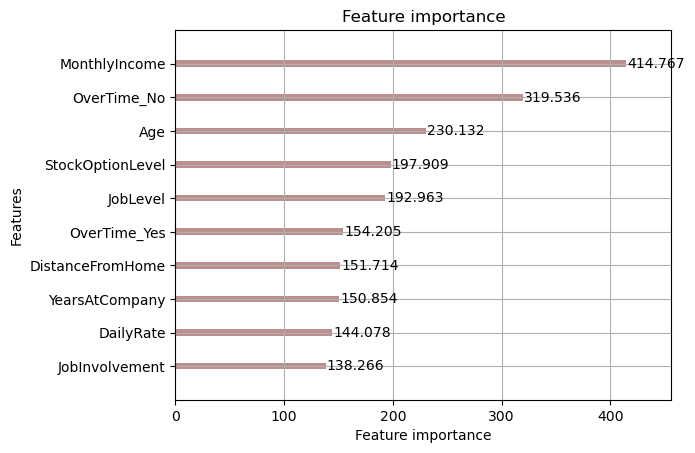

In [12]:
lgb.plot_importance(model, max_num_features = 10, importance_type='gain', color = 'rosybrown')

### <font color='cornflowerblue'> Shap Values

In [13]:
X_shap = X_test.sample(290, random_state=42)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

c:\Users\arant\anaconda3\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


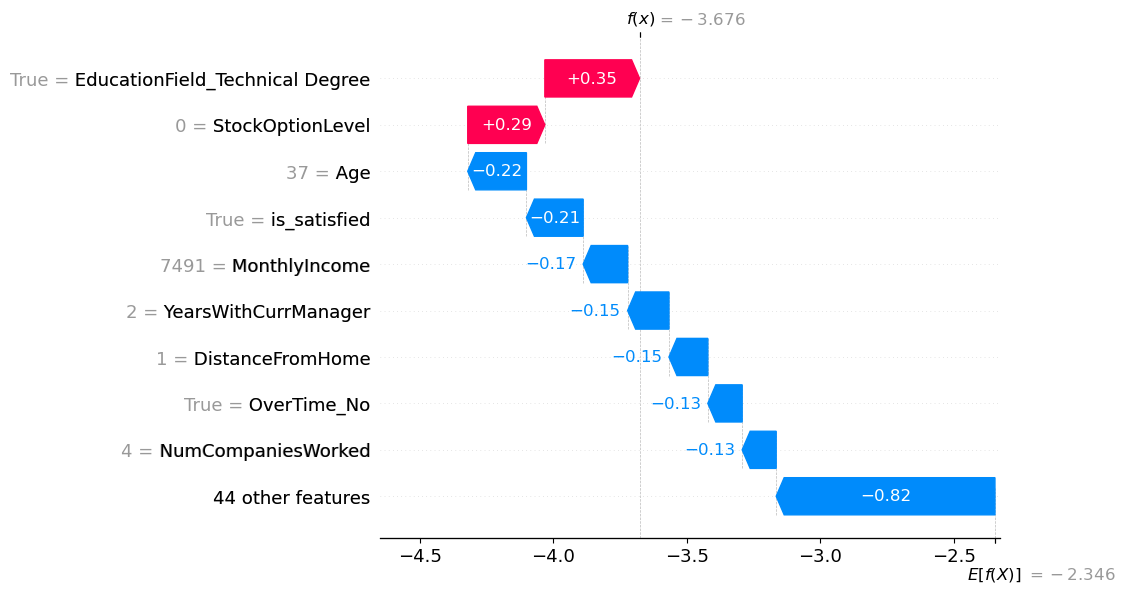

In [14]:
shap.initjs()

shap.plots.waterfall(shap.Explanation(
    values = shap_values[0],
    base_values = explainer.expected_value,
    data = X_shap.iloc[0],
    feature_names = X_shap.keys()
))

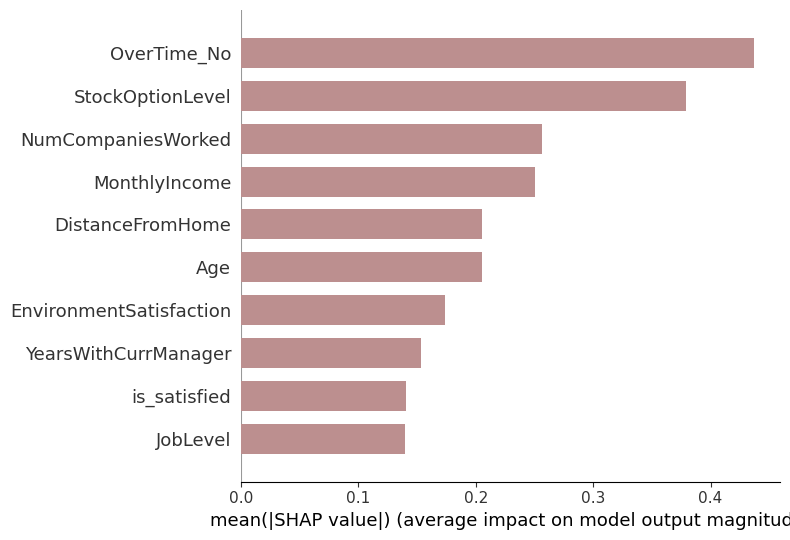

In [15]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display = 10, color = "rosybrown")

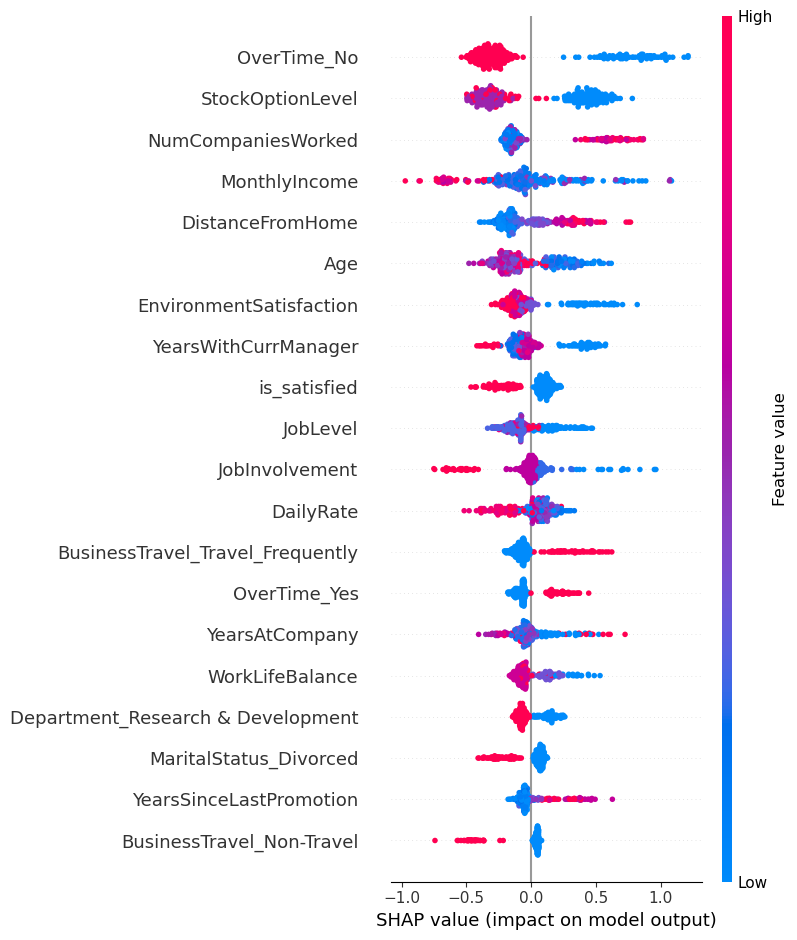

In [16]:
shap.summary_plot(shap_values, X_shap, plot_type="dot")

ANALISIS

## <font color='cornflowerblue'> LightGBM con los componentes principales

In [17]:
x_train_c = x_components.loc[X_train.index]
x_test_c = x_components.loc[X_test.index]

In [18]:
model_c = LGBMClassifier(
    n_estimators=100_000,
    num_leaves=6,
    learning_rate=0.1,
    max_depth=5,
    lambda_l2=0.1,
    subsample=0.8,
    feature_fraction=0.8,
    verbosity=-1
)

model_c.fit(x_train_c, y_train, eval_set=[(x_train_c, y_train), (x_test_c, y_test)],
          eval_metric='auc',
          callbacks=[early_stopping(40),
                     log_evaluation(100)])

predicciones_lgbm_c = model_c.predict_proba(x_test_c)[:,1]
auc_lgbm_c = roc_auc_score(y_test, predicciones_lgbm_c)
auc_lgbm_c

Training until validation scores don't improve for 40 rounds
[100]	training's auc: 0.997439	training's binary_logloss: 0.139845	valid_1's auc: 0.765108	valid_1's binary_logloss: 0.33065
Early stopping, best iteration is:
[69]	training's auc: 0.989599	training's binary_logloss: 0.180534	valid_1's auc: 0.77275	valid_1's binary_logloss: 0.32299


0.7727501256913022

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

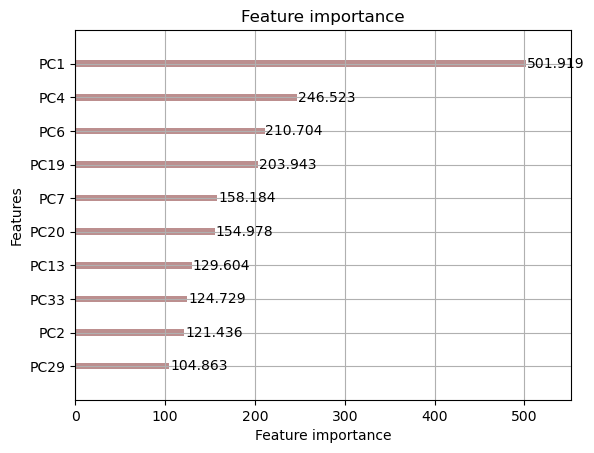

In [19]:
lgb.plot_importance(model_c, max_num_features = 10, importance_type='gain', color = 'rosybrown')

ANALISIS

## <font color='cornflowerblue'> Histogramas

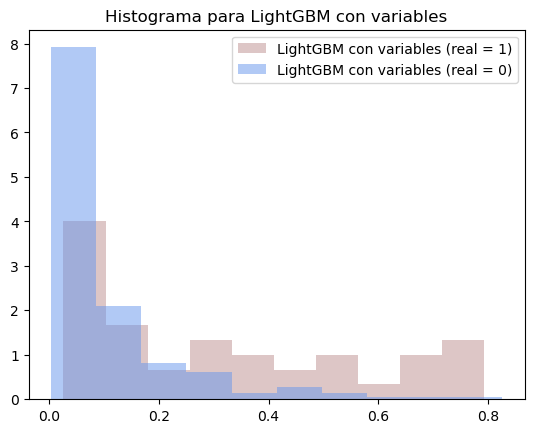

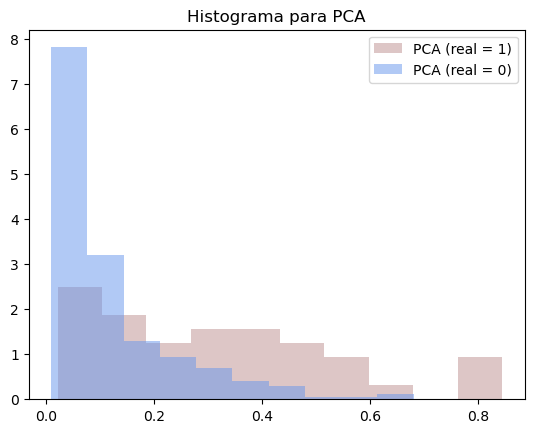

In [20]:
histogramas = pd.DataFrame({
    'real': y_test,
    'LightGBM con variables': predicciones_lgbm,
    'PCA': predicciones_lgbm_c
})

real1 = histogramas[histogramas['real'] == 1]
real0 = histogramas[histogramas['real'] == 0]

modelos = ['LightGBM con variables', 'PCA']

for modelo in modelos:
    plt.hist(real1[modelo], density=True, alpha=0.5, bins=10, color='rosybrown', label=f'{modelo} (real = 1)')
    plt.hist(real0[modelo], density=True, alpha=0.5, bins=10, color='cornflowerblue', label=f'{modelo} (real = 0)')
    plt.title(f'Histograma para {modelo}')
    plt.legend()
    plt.show()

## <font color='cornflowerblue'> Curva ROC

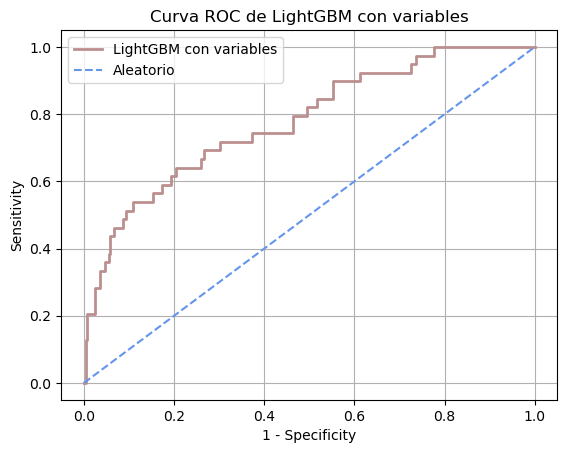

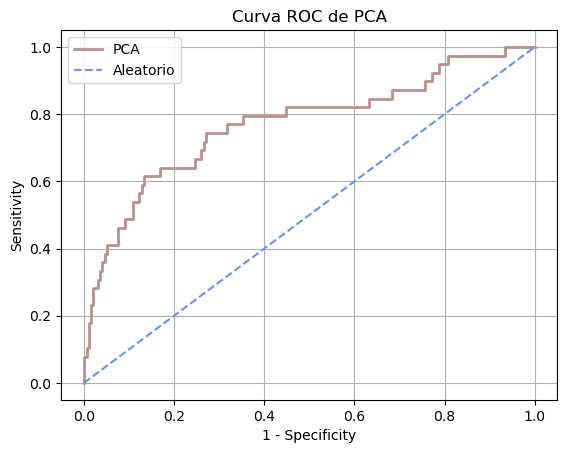

In [21]:
resultados = [predicciones_lgbm, predicciones_lgbm_c]

for i, modelo in enumerate(modelos):
    predicciones = resultados[i]
    fpr, tpr, _ = roc_curve(y_true=y_test, y_score=predicciones) 
    plt.plot(fpr, tpr, label=f'{modelo}', color='rosybrown', lw=2)
    plt.plot([0, 1], [0, 1], color='cornflowerblue', linestyle='--', lw=1.5, label='Aleatorio')
    plt.title(f'Curva ROC de {modelo}')
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.legend()
    plt.grid(True)
    plt.show()

## <font color='cornflowerblue'> AUC

In [22]:
tabla = pd.DataFrame({
    'LightGBM con variables': auc_lgbm,
    'PCA': auc_lgbm_c
}, index=['AUC'])
tabla

,LightGBM con variables,PCA
AUC,0.78009,0.77275


ANALISIS

# <font color='cornflowerblue'> Diabetes

In [23]:
df = pd.read_csv('diabetes.csv')
df['smoking_history'] = df['smoking_history'].map({'No Info': 0, 'never': 0, 'former': 1, 'current': 1, 'not current': 1, 'ever':1})
df = pd.get_dummies(df, columns = ['gender'])

target = 'diabetes'
y = df[target]
X = df.copy()
X = X.drop(target, axis = 1)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## <font color='cornflowerblue'> S Learner

In [25]:
model_t0 = LGBMClassifier(
    n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    eval_metric='auc',
    verbosity=-1  
)

# Entrenar
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), ([X_test, y_test])],
    callbacks=[
        early_stopping(20),
        log_evaluation(100)
    ])

Training until validation scores don't improve for 20 rounds
[100]	training's binary_logloss: 0.225665	valid_1's binary_logloss: 0.228702
Early stopping, best iteration is:
[106]	training's binary_logloss: 0.225518	valid_1's binary_logloss: 0.228667


LGBMClassifier(feature_fraction=0.8, lambda_l2=0.1, max_depth=6,
               n_estimators=100000, num_leaves=10, subsample=0.8, verbosity=-1)

In [26]:
x_test_counter0 = X_test.copy()
x_test_counter0['smoking_history'] = 0

x_test_counter1 = X_test.copy()
x_test_counter1['smoking_history'] = 1

In [27]:
df_cate = pd.DataFrame({
    'treatment0': model.predict_proba(x_test_counter0)[:, 1],
    'treatment1': model.predict_proba(x_test_counter1)[:, 1]
}) 

df_cate['cate'] = df_cate['treatment1'] - df_cate['treatment0']
df_cate.head()

,treatment0,treatment1,cate
0,0.006937,0.007545,0.000608
1,0.000934,0.000973,0.000039
2,0.111697,0.144956,0.033259
3,0.000302,0.000373,0.000071
4,0.061194,0.086956,0.025763


In [28]:
df_cate.cate.describe()


count    20000.000000
mean         0.016756
std          0.015640
min         -0.042059
25%          0.004643
50%          0.012799
75%          0.026369
max          0.231419
Name: cate, dtype: float64

ANALISIS

## <font color='cornflowerblue'> T Learner

In [29]:
X_train_smoke1 = X_train[X_train['smoking_history'] == 1]
y_train_smoke1 = y_train.loc[X_train_smoke1.index]

X_train_smoke0 = X_train[X_train['smoking_history'] == 0]
y_train_smoke0 = y_train.loc[X_train_smoke0.index]

X_test_smoke1 = X_test[X_test['smoking_history'] == 1]
y_test_smoke1 = y_test.loc[X_test_smoke1.index]

X_test_smoke0 = X_test[X_test['smoking_history'] == 0]
y_test_smoke0 = y_test.loc[X_test_smoke0.index]

y_train_smoke = X_train['smoking_history'].reset_index(drop=True)
y_test_smoke = X_test['smoking_history'].reset_index(drop=True)

In [30]:
model_t0 = LGBMClassifier(
    n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)

# Entrenar
model_t0.fit(
    X_train_smoke0, y_train_smoke0,
    eval_set=[(X_train_smoke0, y_train_smoke0), (X_test_smoke0, y_test_smoke0)],
    callbacks=[
        early_stopping(20),
        log_evaluation(100)
    ])

Training until validation scores don't improve for 20 rounds
[100]	training's rmse: 0.230718	valid_1's rmse: 0.23486
Early stopping, best iteration is:
[91]	training's rmse: 0.230855	valid_1's rmse: 0.234845


LGBMClassifier(colsample_bytree=0.8, max_depth=5, metric='rmse',
               n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
               verbosity=-1)

In [31]:
model_t1 = LGBMClassifier(
    n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)

# Entrenar
model_t1.fit(
    X_train_smoke1, y_train_smoke1,
    eval_set=[(X_train_smoke1, y_train_smoke1), (X_test_smoke1, y_test_smoke1)],
    callbacks=[
        early_stopping(20),
        log_evaluation(100)
    ])

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[62]	training's rmse: 0.307573	valid_1's rmse: 0.306103


LGBMClassifier(colsample_bytree=0.8, max_depth=5, metric='rmse',
               n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
               verbosity=-1)

In [32]:
todos = X_test.copy()
todos = todos[X_train_smoke0.keys()]

df_cate = pd.DataFrame({
    'treatment0': model_t0.predict_proba(todos)[:,1],
    'treatment1': model_t1.predict_proba(todos)[:,1]
})

In [33]:
df_cate['cate']= df_cate['treatment1']- df_cate['treatment0']
df_cate.head()

,treatment0,treatment1,cate
0,0.009346,0.007831,-0.001515
1,0.001191,0.007831,0.006640
2,0.127093,0.125018,-0.002075
3,0.000139,0.009024,0.008886
4,0.068442,0.074794,0.006352


In [34]:
df_cate['bin_cate'] = pd.qcut(df_cate['cate'], q = 5, labels = False) + 1
df_cate['diabetes'] = y_test
df_cate.groupby('bin_cate').mean()

,treatment0,treatment1,cate,diabetes
bin_cate,,,,
1,0.087597,0.080106,-0.007491,0.095238
2,0.020352,0.027168,0.006816,0.071605
3,0.033572,0.045685,0.012113,0.087273
4,0.076065,0.099016,0.022951,0.093144
5,0.164070,0.224170,0.060100,0.096081


In [35]:
df_cate.cate.describe()

count    20000.000000
mean         0.018886
std          0.028410
min         -0.403781
25%          0.005537
50%          0.012103
75%          0.027209
max          0.313564
Name: cate, dtype: float64

ANALISIS

## <font color='cornflowerblue'> X Learner

In [36]:
D0 = y_train_smoke1 - model_t0.predict_proba(X_train_smoke1)[:,1]
D1 = model_t1.predict_proba(X_train_smoke0)[:,1]- y_train_smoke0

In [38]:
mD0 = LGBMRegressor(
     n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)
mD0.fit(X_train_smoke1, D0)

LGBMRegressor(colsample_bytree=0.8, max_depth=5, metric='rmse',
              n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
              verbosity=-1)

In [41]:
mD1 = LGBMRegressor(
     n_estimators=10000,
    num_leaves=10,
    max_depth=5,
    learning_rate=0.1,
    colsample_bytree=0.8, 
    subsample=0.8,              
    metric='rmse',
    verbosity=-1,
    n_jobs = -1
)
mD1.fit(X_train_smoke0, D1)

LGBMRegressor(colsample_bytree=0.8, max_depth=5, metric='rmse',
              n_estimators=10000, n_jobs=-1, num_leaves=10, subsample=0.8,
              verbosity=-1)